# **OU Schedule Generation (MNIST)**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
import sys, os
sys.path.append(os.getcwd())

/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models


## Imports

In [ ]:
#%load_ext autoreload
#%autoreload 2

import torch

import sys, os
sys.path.append(os.path.abspath("./"))

import src.diffusion_process as dfp
from src.diffusion_utilities import plot_image_evolution
from src.ou_schedules import (
    make_ou_process_functions,
    make_reverse_drift_coefficient,
    make_ou_probability_flow_drift,
 )
from src.score_model import ScoreNet

## Basic configuration

In [ ]:
if torch.cuda.is_available():
    device_str = "cuda"
elif torch.backends.mps.is_available():
    device_str = "mps"
else:
    device_str = "cpu"

device = torch.device(device_str)
print("Device:", device)

n_threads = torch.get_num_threads()
print("Number of threads:", n_threads)

_ = torch.manual_seed(123)

Device: cuda
Number of threads: 24


## Configure schedule and load checkpoint

In [ ]:
schedule_name = "linear"
sched = make_ou_process_functions(schedule_name)

diffusion_coeff = sched["diffusion_coefficient"]
sigma_t = sched["sigma_t"]

# Define the score model
score_model = ScoreNet(
    marginal_prob_std=sched["sigma_t"],
    in_channels=1,
    out_channels=1
).to(device)

# Load the model checkpoint
epoch = 500
checkpoint_path = f"./checkpoints/mnist_ou_{schedule_name}/checkpoint_ou_{schedule_name}_epoch{epoch}.pth"

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found at: {checkpoint_path}")

score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
score_model.eval()
print(f"Model loaded successfully from: {checkpoint_path}")

Model loaded successfully from: ./checkpoints/mnist_ou_linear/checkpoint_ou_linear_epoch500.pth


## Define backward drift

In [ ]:
backward_drift_coeff = make_reverse_drift_coefficient(sched, score_model)

## Generate images

In [ ]:
n_eval_images = 2000
batch_size = 128
T = 1.0
n_steps = 500

final_images_em_list = []
final_images_ode_list = []
final_images_pc_list = []

probability_flow_drift = make_ou_probability_flow_drift(sched, score_model)

score_model.eval()

with torch.no_grad():
    for start in range(0, n_eval_images, batch_size):
        current_batch = min(batch_size, n_eval_images - start)

        t_T = torch.ones(current_batch, device=device) * T

        image_T = torch.randn(
            current_batch, 1, 32, 32, device=device
        ) * sigma_t(t_T).view(-1, 1, 1, 1)

        _, synthetic_images_em = dfp.euler_maruyama_integrator(
            image_T,
            t_0=T,
            t_end=1.0e-3,
            n_steps=n_steps,
            drift_coefficient=backward_drift_coeff,
            diffusion_coefficient=diffusion_coeff,
        )

        _, synthetic_images_ode = dfp.euler_ode_integrator(
            image_T,
            t_0=T,
            t_end=1.0e-3,
            n_steps=n_steps,
            drift_coefficient=probability_flow_drift,
        )

        _, synthetic_images_pc = dfp.predictor_corrector_sampler(
            image_T,
            t_0=T,
            t_end=1.0e-3,
            n_steps=n_steps,
            drift_coefficient=backward_drift_coeff,
            diffusion_coefficient=diffusion_coeff,
            score_model=score_model,
            n_corrector_steps=1,
            snr=0.16,
            seed=None,
        )

        final_images_em_list.append(synthetic_images_em[..., -1].detach().cpu())
        final_images_ode_list.append(synthetic_images_ode[..., -1].detach().cpu())
        final_images_pc_list.append(synthetic_images_pc[..., -1].detach().cpu())

final_images_em = torch.cat(final_images_em_list, dim=0)
final_images_ode = torch.cat(final_images_ode_list, dim=0)
final_images_pc = torch.cat(final_images_pc_list, dim=0)

print(final_images_em.shape)
print(final_images_ode.shape)
print(final_images_pc.shape)

torch.Size([2000, 1, 32, 32])
torch.Size([2000, 1, 32, 32])
torch.Size([2000, 1, 32, 32])


## Visualize generation evolution

Euler-Maruyama


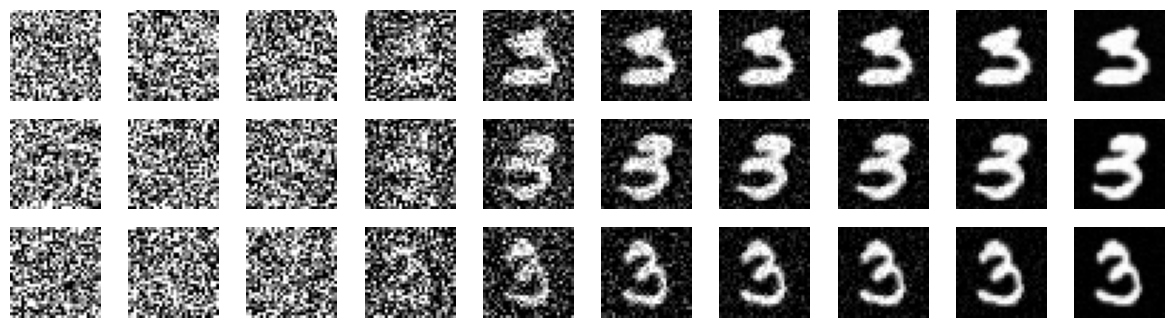

In [ ]:
n_show = 3
indices = torch.randperm(synthetic_images_em.shape[0])[:n_show]

print("Euler-Maruyama")
_ = plot_image_evolution(
    images=synthetic_images_em[indices],
    n_images=n_show,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

ODE (probability flow)


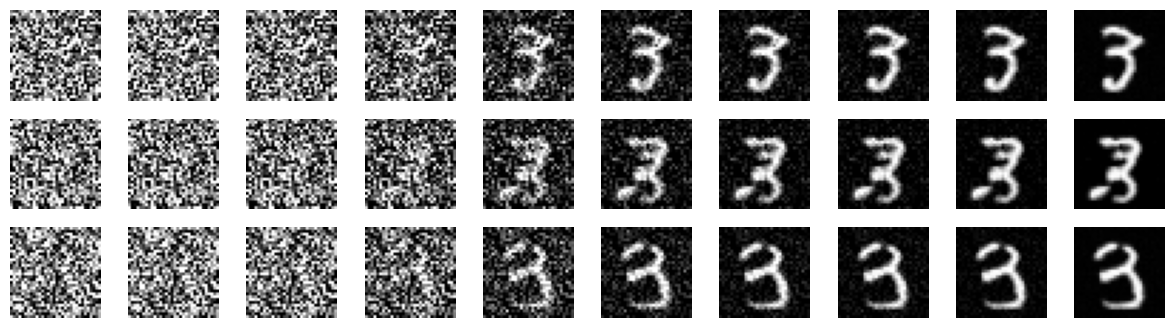

In [ ]:
indices = torch.randperm(synthetic_images_ode.shape[0])[:n_show]

print("ODE (probability flow)")
_ = plot_image_evolution(
    images=synthetic_images_ode[indices],
    n_images=n_show,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

Predictor-Corrector


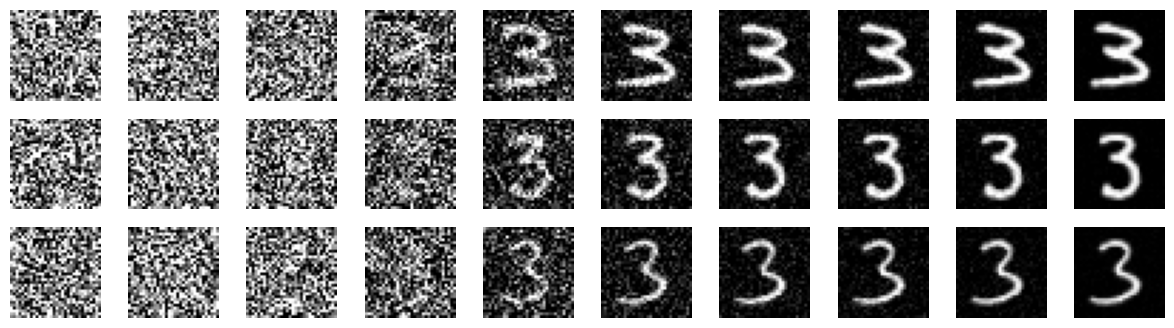

In [ ]:
indices = torch.randperm(synthetic_images_pc.shape[0])[:n_show]

print("Predictor-Corrector")
_ = plot_image_evolution(
    images=synthetic_images_pc[indices],
    n_images=n_show,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

## Save images for measure

In [ ]:
model_tag = f"mnist_ou_{schedule_name}"
save_dir = os.path.join(f"./samples/", model_tag)
os.makedirs(save_dir, exist_ok=True)

sample_file = os.path.join(save_dir, f"final_images_epoch{epoch}.pt")

torch.save(
    {
        "final_images_em": final_images_em,
        "final_images_ode": final_images_ode,
        "final_images_pc": final_images_pc,
    },
    sample_file,
)

print(f"Saved final samples to: {sample_file}")

Saved final samples to: ./samples/mnist_ou_linear/final_images_epoch500.pt
